In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import seaborn as sns
import geopandas as gpd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import pickle
import joblib
import osmnx as ox
import networkx as nx
from datetime import datetime, timedelta
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import duckdb


pd.options.mode.copy_on_write = True

In [3]:
con = duckdb.connect(database='../server/dados_test.db')

In [6]:
con.sql("SELECT * FROM trajectory WHERE trip_number IS NOT NULL")

┌───────┬─────────────────────┬─────────────────────┬────────────────────────────┬─────────────┬──────────────┬────────────────────────┐
│  uid  │      latitude       │      longitude      │         timestamp          │ trip_number │ visit_number │       created_at       │
│ int32 │       double        │       double        │         timestamp          │    int32    │    int32     │       timestamp        │
├───────┼─────────────────────┼─────────────────────┼────────────────────────────┼─────────────┼──────────────┼────────────────────────┤
│     1 │ -25.375679160465115 │ -49.224262504651165 │ 2014-05-19 13:39:09.874821 │           2 │         NULL │ 2025-10-01 12:02:04.84 │
│     1 │  -25.37645733255814 │   -49.2249700255814 │ 2014-05-19 13:39:19.874821 │           2 │         NULL │ 2025-10-01 12:02:04.84 │
│     1 │  -25.37663703798449 │  -49.22541299844961 │ 2014-05-19 13:39:29.874821 │           2 │         NULL │ 2025-10-01 12:02:04.84 │
│     1 │  -25.37662574341085 │  -49.2257

# Achar Sample

In [2]:
df = pd.read_csv('../dados/curitiba_foursquare_purpose.csv')
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


In [3]:
# Convert DATE to datetime and extract date only
df['DATE'] = pd.to_datetime(df['DATE'], utc=True)
df['DATE_ONLY'] = df['DATE'].dt.date

# Count check-ins per user per day
daily_checkins = df.groupby(['ID_USER', 'DATE_ONLY']).size().reset_index(name='checkins_count')

# Find users with exactly 5 check-ins on the same day
users_with_5_checkins = daily_checkins[daily_checkins['checkins_count'] == 5]

print("Users with exactly 5 check-ins on the same day:")
print(f"Found {len(users_with_5_checkins)} users")

# Analyze purpose diversity for each user-day combination with 5 check-ins
diversity_analysis = []

for _, row in users_with_5_checkins.iterrows():
    user_id = row['ID_USER']
    date = row['DATE_ONLY']
    
    user_checkins = df[(df['ID_USER'] == user_id) & (df['DATE_ONLY'] == date)]
    
    # Count unique purposes
    unique_purposes = user_checkins['PURPOSE'].nunique()
    purpose_list = user_checkins['PURPOSE'].unique().tolist()
    
    diversity_analysis.append({
        'ID_USER': user_id,
        'DATE_ONLY': date,
        'unique_purposes': unique_purposes,
        'purposes': purpose_list,
        'checkins_data': user_checkins[['HOUR', 'Bairro', 'CATEGORIA_MAE', 'PURPOSE']].sort_values('HOUR')
    })

# Sort by diversity (number of unique purposes)
diversity_df = pd.DataFrame([{
    'ID_USER': item['ID_USER'],
    'DATE_ONLY': item['DATE_ONLY'],
    'unique_purposes': item['unique_purposes'],
    'purposes': ', '.join(item['purposes'])
} for item in diversity_analysis])

diversity_df = diversity_df.sort_values('unique_purposes', ascending=False)

print("\nUsers with 5 check-ins ranked by purpose diversity:")
print(diversity_df)

# Show the most diverse user's check-ins
if len(diversity_analysis) > 0:
    most_diverse = max(diversity_analysis, key=lambda x: x['unique_purposes'])
    
    print(f"\nMost diverse user: {most_diverse['ID_USER']} on {most_diverse['DATE_ONLY']}")
    print(f"Number of unique purposes: {most_diverse['unique_purposes']}")
    print(f"Purposes: {', '.join(most_diverse['purposes'])}")
    print("\nDetailed check-ins:")
    print(most_diverse['checkins_data'])
    
    # Save this as test data
    test_data = most_diverse['checkins_data'].copy()
    print(f"\nSaving test data for user {most_diverse['ID_USER']}...")
    
# Show top 3 most diverse users
print(f"\nTop 3 most diverse users:")
for i, item in enumerate(sorted(diversity_analysis, key=lambda x: x['unique_purposes'], reverse=True)[:3]):
    print(f"\n{i+1}. User {item['ID_USER']} on {item['DATE_ONLY']}:")
    print(f"   Unique purposes: {item['unique_purposes']}")
    print(f"   Purposes: {', '.join(item['purposes'])}")
    print("   Check-ins:")
    print(item['checkins_data'].to_string(index=False))
    print("-" * 60)

Users with exactly 5 check-ins on the same day:
Found 474 users

Users with 5 check-ins ranked by purpose diversity:
      ID_USER   DATE_ONLY  unique_purposes  \
310  53308444  2014-05-19                5   
37    7461856  2014-05-14                5   
462  84249997  2014-05-28                5   
306  53308444  2014-05-12                5   
448  82458643  2014-05-16                4   
..        ...         ...              ...   
96   12785992  2014-05-17                1   
150  23290602  2014-05-18                1   
144  20611806  2014-06-09                1   
433  81423575  2014-04-28                1   
3     3439053  2014-06-07                1   

                                 purposes  
310  WORK, OTHER, PURCHASE, LEISURE, HOME  
37   OTHER, WORK, HOME, PURCHASE, LEISURE  
462  LEISURE, HOME, OTHER, PURCHASE, WORK  
306  WORK, OTHER, PURCHASE, LEISURE, HOME  
448         LEISURE, HOME, WORK, PURCHASE  
..                                    ...  
96                    

In [4]:
diversity_df.head(20)

,ID_USER,DATE_ONLY,unique_purposes,purposes
310,53308444,2014-05-19,5,"WORK, OTHER, PURCHASE, LEISURE, HOME"
37,7461856,2014-05-14,5,"OTHER, WORK, HOME, PURCHASE, LEISURE"
462,84249997,2014-05-28,5,"LEISURE, HOME, OTHER, PURCHASE, WORK"
306,53308444,2014-05-12,5,"WORK, OTHER, PURCHASE, LEISURE, HOME"
448,82458643,2014-05-16,4,"LEISURE, HOME, WORK, PURCHASE"
445,82458643,2014-05-02,4,"WORK, PURCHASE, LEISURE, HOME"
1,1200333,2014-05-14,4,"HOME, LEISURE, OTHER, WORK"
450,82458643,2014-06-07,4,"HOME, WORK, LEISURE, PURCHASE"
32,6841680,2014-05-27,4,"OTHER, WORK, LEISURE, PURCHASE"
27,5896225,2014-05-19,4,"LEISURE, HOME, WORK, PURCHASE"


# Gerar Trajetória

In [5]:
sample_df = df[(df["ID_USER"] == 53308444) & (df["DATE_ONLY"] == pd.to_datetime("2014-05-19").date())]
sample_df = sample_df.sort_values("HOUR")
sample_df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE,DATE_ONLY
30747,53308444,2014-05-19 10:51:41+00:00,High-School,SANTA CÂNDIDA,-25.374541,-49.224360,7,0,Monday,WORK,2014-05-19
31278,53308444,2014-05-19 17:06:07+00:00,Building,CENTRO CÍVICO,-25.418538,-49.268290,14,0,Monday,OTHER,2014-05-19
31456,53308444,2014-05-19 20:08:24+00:00,Bank,CENTRO CÍVICO,-25.420326,-49.269062,17,0,Monday,PURCHASE,2014-05-19
31610,53308444,2014-05-19 21:53:25+00:00,Sandwiches,ALTO DA GLÓRIA,-25.417994,-49.262153,18,0,Monday,LEISURE,2014-05-19
31746,53308444,2014-05-19 22:56:12+00:00,Residential,BACACHERI,-25.392531,-49.229802,19,0,Monday,HOME,2014-05-19


In [6]:
# Extract coordinates from the sample data
locations = []
for _, row in sample_df.iterrows():
    locations.append((row['LAT'], row['LONG']))

print(f"Number of check-ins: {len(locations)}")
print("Check-in locations (lat, lon):")
for i, loc in enumerate(locations):
    print(f"{i+1}. {loc} - {sample_df.iloc[i]['CATEGORIA_MAE']} at hour {sample_df.iloc[i]['HOUR']}")

# Get the center point for downloading the street network
center_lat = sample_df['LAT'].mean()
center_lon = sample_df['LONG'].mean()
center_coords = (center_lat, center_lon)

print(f"\nCenter coordinates: {center_coords}")

# Download the street network for Curitiba area
# Using a larger distance to cover all check-in points
G = ox.graph_from_point(center_coords, dist=10000, network_type='drive')

print(f"Downloaded street network with {len(G.nodes)} nodes and {len(G.edges)} edges")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.374540548, -49.2243601686) - High-School at hour 7
2. (-25.4185378571, -49.2682900524) - Building at hour 14
3. (-25.4203256745, -49.2690621799) - Bank at hour 17
4. (-25.4179939823, -49.2621529964) - Sandwiches at hour 18
5. (-25.392531, -49.229802) - Residential at hour 19

Center coordinates: (np.float64(-25.404785812380002), np.float64(-49.25073347946))
Downloaded street network with 30096 nodes and 77290 edges


In [7]:
# Find the nearest network nodes for each check-in location
nodes = ox.nearest_nodes(G, [loc[1] for loc in locations], [loc[0] for loc in locations])

print(f"Found nearest network nodes: {nodes}")

# Calculate the full trajectory by connecting all check-ins in chronological order
full_route = []
total_distance = 0

for i in range(len(nodes) - 1):
    try:
        route_segment = nx.shortest_path(G, source=nodes[i], target=nodes[i+1], weight='length')
        
        # Calculate segment distance
        segment_distance = nx.shortest_path_length(G, source=nodes[i], target=nodes[i+1], weight='length')
        total_distance += segment_distance
        
        print(f"Segment {i+1}: {len(route_segment)} nodes, {segment_distance:.0f} meters")
        
        # Add to full route (avoid duplicating nodes between segments)
        if i == 0:
            full_route.extend(route_segment)
        else:
            full_route.extend(route_segment[1:])  # Skip first node to avoid duplication
            
    except nx.NetworkXNoPath:
        print(f"Warning: No path found between check-ins {i+1} and {i+2}")

print(f"\nTotal trajectory: {len(full_route)} nodes, {total_distance:.0f} meters total distance")

Found nearest network nodes: [5837368337 5265917367 3610984066  865726774 1408449258]
Segment 1: 63 nodes, 7223 meters
Segment 2: 11 nodes, 1434 meters
Segment 3: 8 nodes, 877 meters
Segment 4: 43 nodes, 4672 meters

Total trajectory: 122 nodes, 14206 meters total distance


In [8]:
def create_street_following_trajectory(sample_df, full_route, G, nodes):
    """
    Create a detailed trajectory that follows the actual street network.
    Travel time is calculated based on actual distance at 60 km/h.
    
    Returns:
        DataFrame with timestamp, lat, lon following street network
    """
    trajectory_data = []
    
    # Sort by hour to ensure chronological order
    sample_df_sorted = sample_df.sort_values('HOUR').reset_index(drop=True)
    base_date = pd.to_datetime(sample_df_sorted.iloc[0]['DATE']).date()
    
    # Get coordinates for all nodes in the route
    route_coords = []
    for node in full_route:
        route_coords.append((G.nodes[node]['y'], G.nodes[node]['x']))  # lat, lon
    
    # Create segments between check-ins
    for i in range(len(sample_df_sorted)):
        current_row = sample_df_sorted.iloc[i]
        current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
        
        # Calculate travel time and stay time
        if i < len(sample_df_sorted) - 1:
            next_hour = int(sample_df_sorted.iloc[i + 1]['HOUR'])
            total_time_minutes = (next_hour - int(current_row['HOUR'])) * 60
            
            # Calculate actual travel distance between current and next check-in
            try:
                # Get route distance in meters
                route_distance = nx.shortest_path_length(G, source=nodes[i], target=nodes[i+1], weight='length')
                
                # Calculate travel time at 20 km/h
                speed_ms = 20000 / 3600  # 20 km/h in meters per second (5.56 m/s)
                travel_time_minutes = (route_distance / speed_ms) / 60  # Convert to minutes
                
                # Ensure travel time doesn't exceed total available time
                travel_time_minutes = min(travel_time_minutes, total_time_minutes * 0.9)  # Max 90% of time for travel
                time_at_location_minutes = total_time_minutes - travel_time_minutes
                
                print(f"Segment {i+1}: Distance={route_distance:.0f}m, Travel time={travel_time_minutes:.1f}min, Stay time={time_at_location_minutes:.1f}min")
                
            except (nx.NetworkXNoPath, KeyError):
                # Fallback to old method if no path found
                print(f"Warning: No path found for segment {i+1}, using fallback timing")
                time_at_location_minutes = total_time_minutes * 0.8
                travel_time_minutes = total_time_minutes * 0.2
        else:
            time_at_location_minutes = 60  # 1 hour at last location
            travel_time_minutes = 0
        
        # Add intervals at current location
        intervals_at_location = int((time_at_location_minutes * 60) // 10)  # 10-second intervals
        for j in range(intervals_at_location):
            timestamp = current_timestamp + timedelta(seconds=j * 10)
            trajectory_data.append({
                'timestamp': timestamp,
                'lat': current_row['LAT'],
                'lon': current_row['LONG']
            })
        
        # Add travel intervals following street network (if not last location)
        if i < len(sample_df_sorted) - 1 and travel_time_minutes > 0:
            travel_start_time = current_timestamp + timedelta(minutes=time_at_location_minutes)
            travel_intervals = int((travel_time_minutes * 60) // 10)  # 10-second intervals
            
            # Find the route segment for this travel
            current_node_idx = None
            next_node_idx = None
            
            # Find the indices in full_route corresponding to current and next check-ins
            for idx, node in enumerate(full_route):
                if node == nodes[i]:
                    current_node_idx = idx
                if node == nodes[i + 1]:
                    next_node_idx = idx
                    break
            
            if current_node_idx is not None and next_node_idx is not None:
                # Get the route segment between these points
                segment_nodes = full_route[current_node_idx:next_node_idx + 1]
                segment_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in segment_nodes]
                
                # Distribute travel intervals along the segment
                if len(segment_coords) > 1:
                    for j in range(travel_intervals):
                        if travel_intervals > 1:
                            progress = j / (travel_intervals - 1)  # Ensure we reach the end
                        else:
                            progress = 1.0
                        
                        # Find which segment of the route we're on
                        segment_position = progress * (len(segment_coords) - 1)
                        segment_idx = int(segment_position)
                        local_progress = segment_position - segment_idx
                        
                        if segment_idx < len(segment_coords) - 1:
                            # Interpolate between two consecutive route points
                            lat1, lon1 = segment_coords[segment_idx]
                            lat2, lon2 = segment_coords[segment_idx + 1]
                            
                            interpolated_lat = lat1 + (lat2 - lat1) * local_progress
                            interpolated_lon = lon1 + (lon2 - lon1) * local_progress
                        else:
                            # Last point
                            interpolated_lat, interpolated_lon = segment_coords[-1]
                        
                        travel_timestamp = travel_start_time + timedelta(seconds=j * 10)
                        trajectory_data.append({
                            'timestamp': travel_timestamp,
                            'lat': interpolated_lat,
                            'lon': interpolated_lon
                        })
    
    # Create DataFrame
    trajectory_df = pd.DataFrame(trajectory_data)
    trajectory_df = trajectory_df.sort_values('timestamp').reset_index(drop=True)
    
    return trajectory_df

# Generate the improved trajectory that follows streets with realistic travel times
street_trajectory = create_street_following_trajectory(sample_df, full_route, G, nodes)

print(f"\nGenerated street-following trajectory with {len(street_trajectory)} data points")
print(f"Time span: {street_trajectory['timestamp'].min()} to {street_trajectory['timestamp'].max()}")
print(f"Total duration: {(street_trajectory['timestamp'].max() - street_trajectory['timestamp'].min()).total_seconds() / 3600:.2f} hours")

# Save the improved trajectory
# street_trajectory.to_csv('../dados/realistic_street_following_trajectory_user_7461856.csv', index=False)
print(f"Realistic street-following trajectory saved")

# Display sample
print("\nFirst 20 rows of street-following trajectory:")
print(street_trajectory.head(20))

Segment 1: Distance=7223m, Travel time=21.7min, Stay time=398.3min
Segment 2: Distance=1434m, Travel time=4.3min, Stay time=175.7min
Segment 3: Distance=877m, Travel time=2.6min, Stay time=57.4min
Segment 4: Distance=4672m, Travel time=14.0min, Stay time=46.0min

Generated street-following trajectory with 4676 data points
Time span: 2014-05-19 07:00:00 to 2014-05-19 19:59:50
Total duration: 13.00 hours
Realistic street-following trajectory saved

First 20 rows of street-following trajectory:
             timestamp        lat       lon
0  2014-05-19 07:00:00 -25.374541 -49.22436
1  2014-05-19 07:00:10 -25.374541 -49.22436
2  2014-05-19 07:00:20 -25.374541 -49.22436
3  2014-05-19 07:00:30 -25.374541 -49.22436
4  2014-05-19 07:00:40 -25.374541 -49.22436
5  2014-05-19 07:00:50 -25.374541 -49.22436
6  2014-05-19 07:01:00 -25.374541 -49.22436
7  2014-05-19 07:01:10 -25.374541 -49.22436
8  2014-05-19 07:01:20 -25.374541 -49.22436
9  2014-05-19 07:01:30 -25.374541 -49.22436
10 2014-05-19 07:01

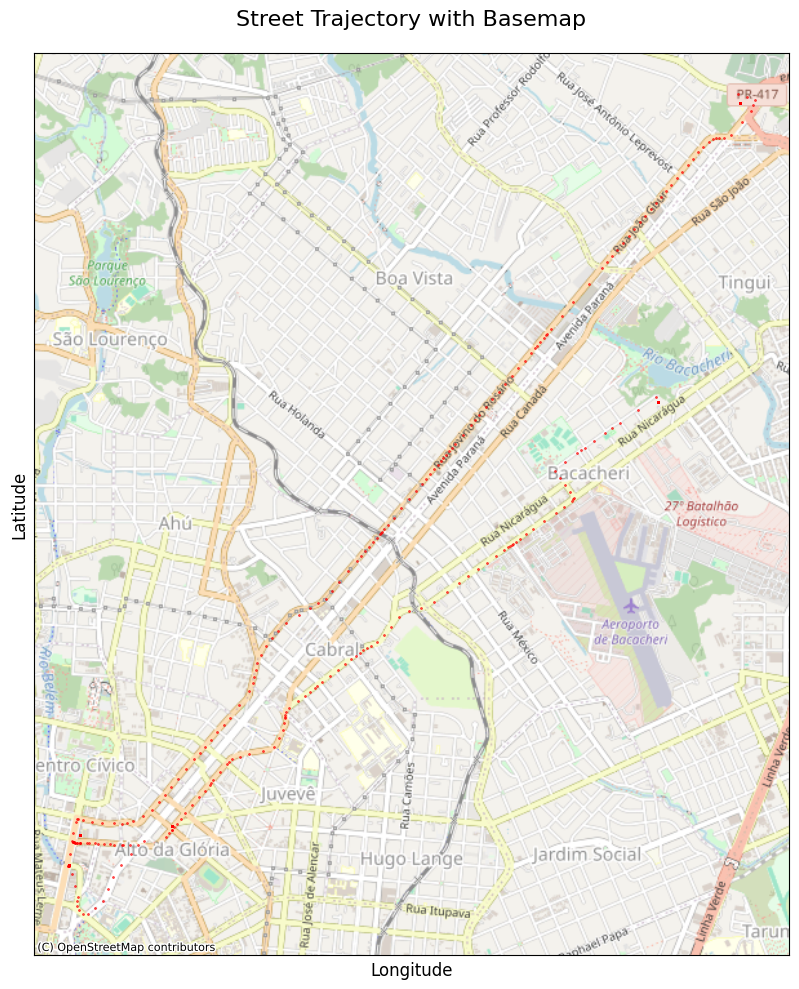

In [9]:
street_trajectory_gdf = gpd.GeoDataFrame(
    street_trajectory,
    geometry=gpd.points_from_xy(street_trajectory['lon'], street_trajectory['lat']),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 10))

# Convert to Web Mercator for basemap compatibility
street_trajectory_gdf_mercator = street_trajectory_gdf.to_crs(epsg=3857)


# Plot the trajectory points
street_trajectory_gdf_mercator.plot(
    ax=ax, 
    markersize=2, 
    alpha=0.7, 
    color='red',
    linewidth=0.5
)

# Add basemap
ctx.add_basemap(
    ax, 
    crs=street_trajectory_gdf_mercator.crs.to_string(),
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.8
)

# Set title and remove axis ticks for cleaner look
ax.set_title('Street Trajectory with Basemap', fontsize=16, pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Remove axis for cleaner look
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [13]:
def identify_stationary_points(trajectory_gdf, eps_meters=50, min_samples=10):
    """
    Use DBSCAN to identify stationary points vs trajectory points.
    
    Parameters:
    - trajectory_gdf: GeoDataFrame with trajectory points
    - eps_meters: maximum distance (in meters) between points in a cluster
    - min_samples: minimum number of points to form a stationary cluster
    
    Returns:
    - GeoDataFrame with additional columns: 'cluster', 'is_stationary', 'stationary_label'
    """
    # Convert to a projected CRS for distance calculations in meters
    gdf_projected = trajectory_gdf.to_crs(epsg=3857)
    
    # Extract coordinates for clustering
    coords = np.column_stack([gdf_projected.geometry.x, gdf_projected.geometry.y])
    
    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps_meters, min_samples=min_samples, metric='euclidean')
    clusters = dbscan.fit_predict(coords)
    
    # Add cluster labels to dataframe
    result_gdf = trajectory_gdf.copy()
    result_gdf['cluster'] = clusters
    
    # Mark stationary points (clusters != -1) and trajectory points (cluster == -1)
    result_gdf['is_stationary'] = result_gdf['cluster'] != -1
    
    # Create readable labels
    result_gdf['stationary_label'] = result_gdf.apply(
        lambda row: f"Stationary_{row['cluster']}" if row['is_stationary'] else "Trajectory",
        axis=1
    )
    
    # Calculate statistics
    n_stationary = result_gdf['is_stationary'].sum()
    n_trajectory = (~result_gdf['is_stationary']).sum()
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    
    print(f"DBSCAN Results:")
    print(f"- Total points: {len(result_gdf)}")
    print(f"- Stationary points: {n_stationary} ({n_stationary/len(result_gdf)*100:.1f}%)")
    print(f"- Trajectory points: {n_trajectory} ({n_trajectory/len(result_gdf)*100:.1f}%)")
    print(f"- Number of stationary clusters: {n_clusters}")
    
    # Print cluster statistics
    if n_clusters > 0:
        print(f"\nCluster details:")
        for cluster_id in sorted(result_gdf[result_gdf['is_stationary']]['cluster'].unique()):
            cluster_points = result_gdf[result_gdf['cluster'] == cluster_id]
            duration_seconds = (cluster_points['timestamp'].max() - cluster_points['timestamp'].min()).total_seconds()
            print(f"  Cluster {cluster_id}: {len(cluster_points)} points, "
                  f"{duration_seconds/60:.1f} minutes")
    
    return result_gdf

# Apply DBSCAN to identify stationary points
street_trajectory_with_clusters = identify_stationary_points(
    street_trajectory_gdf, 
    eps_meters=50,  # Points within 50 meters are considered same location
    min_samples=60   # At least 60 points (600 seconds) to be stationary
)

# Display results
print("\nFirst 20 rows with cluster information:")
print(street_trajectory_with_clusters[['timestamp', 'lat', 'lon', 'cluster', 'is_stationary', 'stationary_label']].head(20))

DBSCAN Results:
- Total points: 4676
- Stationary points: 4433 (94.8%)
- Trajectory points: 243 (5.2%)
- Number of stationary clusters: 5

Cluster details:
  Cluster 0: 2389 points, 398.0 minutes
  Cluster 1: 1054 points, 175.5 minutes
  Cluster 2: 348 points, 58.0 minutes
  Cluster 3: 281 points, 46.9 minutes
  Cluster 4: 361 points, 60.0 minutes

First 20 rows with cluster information:
             timestamp        lat       lon  cluster  is_stationary  \
0  2014-05-19 07:00:00 -25.374541 -49.22436        0           True   
1  2014-05-19 07:00:10 -25.374541 -49.22436        0           True   
2  2014-05-19 07:00:20 -25.374541 -49.22436        0           True   
3  2014-05-19 07:00:30 -25.374541 -49.22436        0           True   
4  2014-05-19 07:00:40 -25.374541 -49.22436        0           True   
5  2014-05-19 07:00:50 -25.374541 -49.22436        0           True   
6  2014-05-19 07:01:00 -25.374541 -49.22436        0           True   
7  2014-05-19 07:01:10 -25.374541 -49.224

In [10]:
street_trajectory_gdf

,timestamp,lat,lon,geometry
0,2014-05-19 07:00:00,-25.374541,-49.224360,POINT (-49.22436 -25.37454)
1,2014-05-19 07:00:10,-25.374541,-49.224360,POINT (-49.22436 -25.37454)
2,2014-05-19 07:00:20,-25.374541,-49.224360,POINT (-49.22436 -25.37454)
3,2014-05-19 07:00:30,-25.374541,-49.224360,POINT (-49.22436 -25.37454)
4,2014-05-19 07:00:40,-25.374541,-49.224360,POINT (-49.22436 -25.37454)
...,...,...,...,...
4671,2014-05-19 19:59:10,-25.392531,-49.229802,POINT (-49.2298 -25.39253)
4672,2014-05-19 19:59:20,-25.392531,-49.229802,POINT (-49.2298 -25.39253)
4673,2014-05-19 19:59:30,-25.392531,-49.229802,POINT (-49.2298 -25.39253)
4674,2014-05-19 19:59:40,-25.392531,-49.229802,POINT (-49.2298 -25.39253)


In [39]:
street_trajectory_gdf.to_csv('../dados/sample_detailed_trajectory_user_53308444_2.csv', index=False)

# Big Function to test

In [50]:
def get_and_save_trajectory(user_id, date_str):
    sample_df = df[(df["ID_USER"] == user_id) & (df["DATE_ONLY"] == pd.to_datetime(date_str).date())]
    sample_df = sample_df.sort_values("HOUR")
    

    # Extract coordinates from the sample data
    locations = []
    for _, row in sample_df.iterrows():
        locations.append((row['LAT'], row['LONG']))

    print(f"Number of check-ins: {len(locations)}")
    print("Check-in locations (lat, lon):")
    for i, loc in enumerate(locations):
        print(f"{i+1}. {loc} - {sample_df.iloc[i]['CATEGORIA_MAE']} at hour {sample_df.iloc[i]['HOUR']}")

    # Get the center point for downloading the street network
    center_lat = sample_df['LAT'].mean()
    center_lon = sample_df['LONG'].mean()
    center_coords = (center_lat, center_lon)

    print(f"\nCenter coordinates: {center_coords}")

    # Download the street network for Curitiba area
    # Using a larger distance to cover all check-in points
    G = ox.graph_from_point(center_coords, dist=10000, network_type='drive')

    print(f"Downloaded street network with {len(G.nodes)} nodes and {len(G.edges)} edges")

    # Find the nearest network nodes for each check-in location
    nodes = ox.nearest_nodes(G, [loc[1] for loc in locations], [loc[0] for loc in locations])

    print(f"Found nearest network nodes: {nodes}")

    # Calculate the full trajectory by connecting all check-ins in chronological order
    full_route = []
    total_distance = 0

    for i in range(len(nodes) - 1):
        try:
            route_segment = nx.shortest_path(G, source=nodes[i], target=nodes[i+1], weight='length')
            
            # Calculate segment distance
            segment_distance = nx.shortest_path_length(G, source=nodes[i], target=nodes[i+1], weight='length')
            total_distance += segment_distance
            
            print(f"Segment {i+1}: {len(route_segment)} nodes, {segment_distance:.0f} meters")
            
            # Add to full route (avoid duplicating nodes between segments)
            if i == 0:
                full_route.extend(route_segment)
            else:
                full_route.extend(route_segment[1:])  # Skip first node to avoid duplication
                
        except nx.NetworkXNoPath:
            print(f"Warning: No path found between check-ins {i+1} and {i+2}")

    print(f"\nTotal trajectory: {len(full_route)} nodes, {total_distance:.0f} meters total distance")

    street_trajectory = create_street_following_trajectory(sample_df, full_route, G, nodes)

    print(f"\nGenerated street-following trajectory with {len(street_trajectory)} data points")
    print(f"Time span: {street_trajectory['timestamp'].min()} to {street_trajectory['timestamp'].max()}")
    print(f"Total duration: {(street_trajectory['timestamp'].max() - street_trajectory['timestamp'].min()).total_seconds() / 3600:.2f} hours")

    # Save the improved trajectory
    # street_trajectory.to_csv('../dados/realistic_street_following_trajectory_user_7461856.csv', index=False)
    print(f"Realistic street-following trajectory saved")

    # Display sample
    print("\nFirst 20 rows of street-following trajectory:")
    print(street_trajectory.head(20))

    street_trajectory_gdf = gpd.GeoDataFrame(
        street_trajectory,
        geometry=gpd.points_from_xy(street_trajectory['lon'], street_trajectory['lat']),
        crs="EPSG:4326"
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    # Convert to Web Mercator for basemap compatibility
    street_trajectory_gdf_mercator = street_trajectory_gdf.to_crs(epsg=3857)


    # Plot the trajectory points
    street_trajectory_gdf_mercator.plot(
        ax=ax, 
        markersize=20, 
        alpha=0.9, 
        color='red',
        linewidth=0.5
    )

    # Add basemap
    ctx.add_basemap(
        ax, 
        crs=street_trajectory_gdf_mercator.crs.to_string(),
        source=ctx.providers.OpenStreetMap.Mapnik,
        alpha=0.8
    )

    # Set title and remove axis ticks for cleaner look
    # ax.set_title('Street Trajectory with Basemap', fontsize=16, pad=20)
    # ax.set_xlabel('Longitude', fontsize=12)
    # ax.set_ylabel('Latitude', fontsize=12)

    # Remove axis for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    street_trajectory_gdf.to_csv(f'../dados/sample_detailed_trajectory_user_{user_id}_{date_str}.csv', index=False)


Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.4321907355, -49.2744541168) - Plaza at hour 8
2. (-25.4322164609, -49.2743634111) - Building at hour 8
3. (-25.432093844, -49.2741751671) - Office at hour 8
4. (-25.4366927703, -49.2835909916) - School at hour 12
5. (-25.4313851197, -49.258800163) - Home at hour 22

Center coordinates: (np.float64(-25.43291578608), np.float64(-49.273076769919996))
Downloaded street network with 32676 nodes and 84381 edges
Found nearest network nodes: [4159411204 4159411204 4159411204  324724600 4035000322]
Segment 1: 1 nodes, 0 meters
Segment 2: 1 nodes, 0 meters
Segment 3: 12 nodes, 1380 meters
Segment 4: 30 nodes, 2753 meters

Total trajectory: 41 nodes, 4133 meters total distance
Segment 1: Distance=0m, Travel time=0.0min, Stay time=0.0min
Segment 2: Distance=0m, Travel time=0.0min, Stay time=0.0min
Segment 3: Distance=1380m, Travel time=4.1min, Stay time=235.9min
Segment 4: Distance=2753m, Travel time=8.3min, Stay time=591.7min

Generate

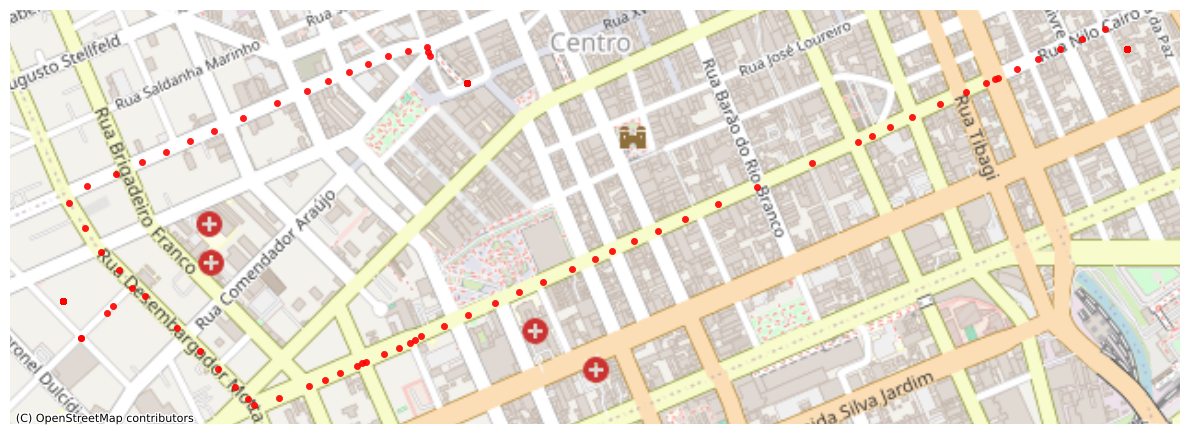

In [57]:
get_and_save_trajectory(1200333, "2014-05-14")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.374540548, -49.2243601686) - High-School at hour 7
2. (-25.4185378571, -49.2682900524) - Building at hour 15
3. (-25.4232860784, -49.2704737186) - Mall at hour 18
4. (-25.4229663125, -49.2702913284) - Burgers at hour 19
5. (-25.392531, -49.229802) - Residential at hour 20

Center coordinates: (np.float64(-25.4063723592), np.float64(-49.2526434536))
Downloaded street network with 30352 nodes and 77961 edges
Found nearest network nodes: [5837368337 5265917367 5268327336 5268327336 1408449258]
Segment 1: 63 nodes, 7223 meters
Segment 2: 14 nodes, 1380 meters
Segment 3: 1 nodes, 0 meters
Segment 4: 61 nodes, 6321 meters

Total trajectory: 136 nodes, 14924 meters total distance
Segment 1: Distance=7223m, Travel time=21.7min, Stay time=458.3min
Segment 2: Distance=1380m, Travel time=4.1min, Stay time=175.9min
Segment 3: Distance=0m, Travel time=0.0min, Stay time=60.0min
Segment 4: Distance=6321m, Travel time=19.0min, Stay time=41.

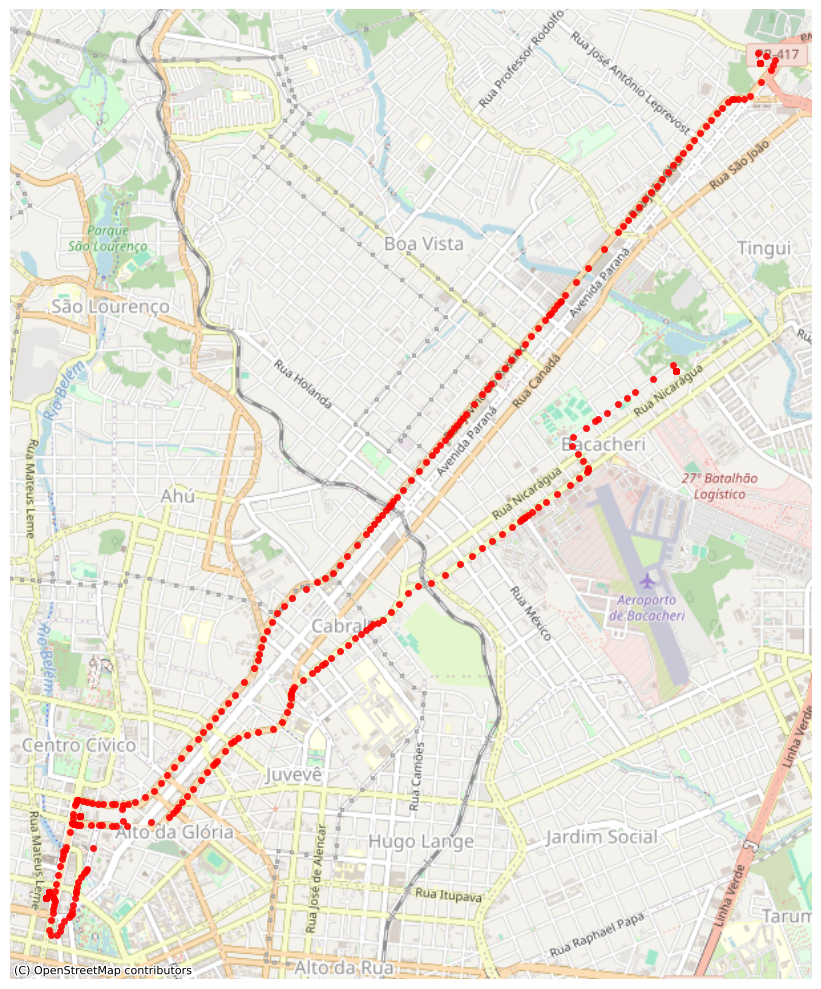

In [52]:
get_and_save_trajectory(53308444, "2014-05-12")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.4580987509, -49.309496985) - Home at hour 10
2. (-25.4658293325, -49.2964992072) - School at hour 15
3. (-25.4660356769, -49.2959743059) - Athletics-&-Sports at hour 16
4. (-25.4715610012, -49.2959117889) - Supermarket at hour 18
5. (-25.4580987509, -49.309496985) - Home at hour 18

Center coordinates: (np.float64(-25.46392470248), np.float64(-49.30147585440001))
Downloaded street network with 29886 nodes and 76929 edges
Found nearest network nodes: [1425481275  472525791  472525791  474201196 1425481275]
Segment 1: 28 nodes, 2222 meters
Segment 2: 1 nodes, 0 meters
Segment 3: 8 nodes, 484 meters
Segment 4: 27 nodes, 2694 meters

Total trajectory: 61 nodes, 5400 meters total distance
Segment 1: Distance=2222m, Travel time=6.7min, Stay time=293.3min
Segment 2: Distance=0m, Travel time=0.0min, Stay time=60.0min
Segment 3: Distance=484m, Travel time=1.5min, Stay time=118.5min
Segment 4: Distance=2694m, Travel time=0.0min, Stay 

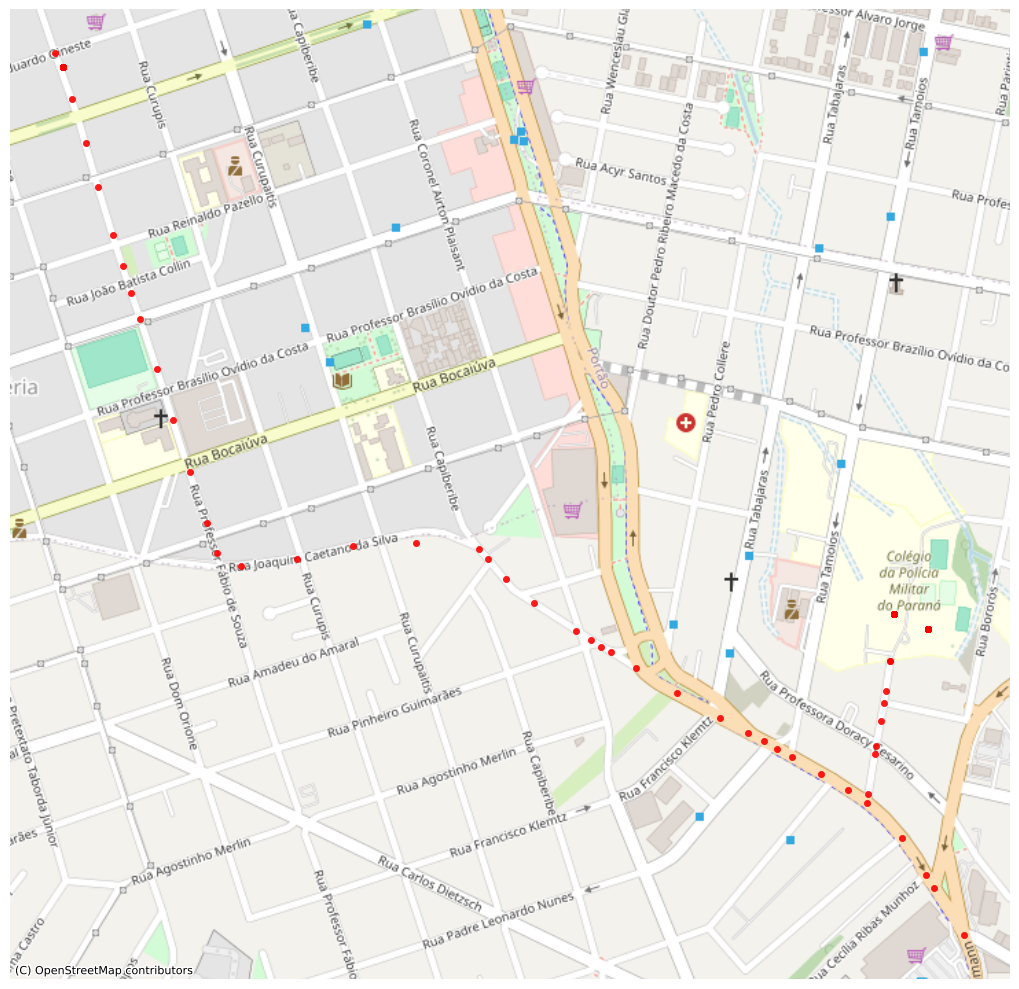

In [58]:
get_and_save_trajectory(82458643, "2014-06-07")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.4244197873, -49.274148345) - Nightclub at hour 0
2. (-25.4347292659, -49.2840886116) - Lounge at hour 2
3. (-25.4381591036, -49.2663860321) - Burgers at hour 16
4. (-25.4356703229, -49.2663152349) - Hotel at hour 20
5. (-25.4248683794, -49.2740169105) - Burgers at hour 23

Center coordinates: (np.float64(-25.431569371819997), np.float64(-49.27299102682))
Downloaded street network with 32650 nodes and 84308 edges
Found nearest network nodes: [ 324344764 3605030038 1229556438 1738398160  324344764]
Segment 1: 19 nodes, 1864 meters
Segment 2: 29 nodes, 2959 meters
Segment 3: 9 nodes, 1165 meters
Segment 4: 20 nodes, 1933 meters

Total trajectory: 74 nodes, 7921 meters total distance
Segment 1: Distance=1864m, Travel time=5.6min, Stay time=114.4min
Segment 2: Distance=2959m, Travel time=8.9min, Stay time=831.1min
Segment 3: Distance=1165m, Travel time=3.5min, Stay time=236.5min
Segment 4: Distance=1933m, Travel time=5.8min, Stay

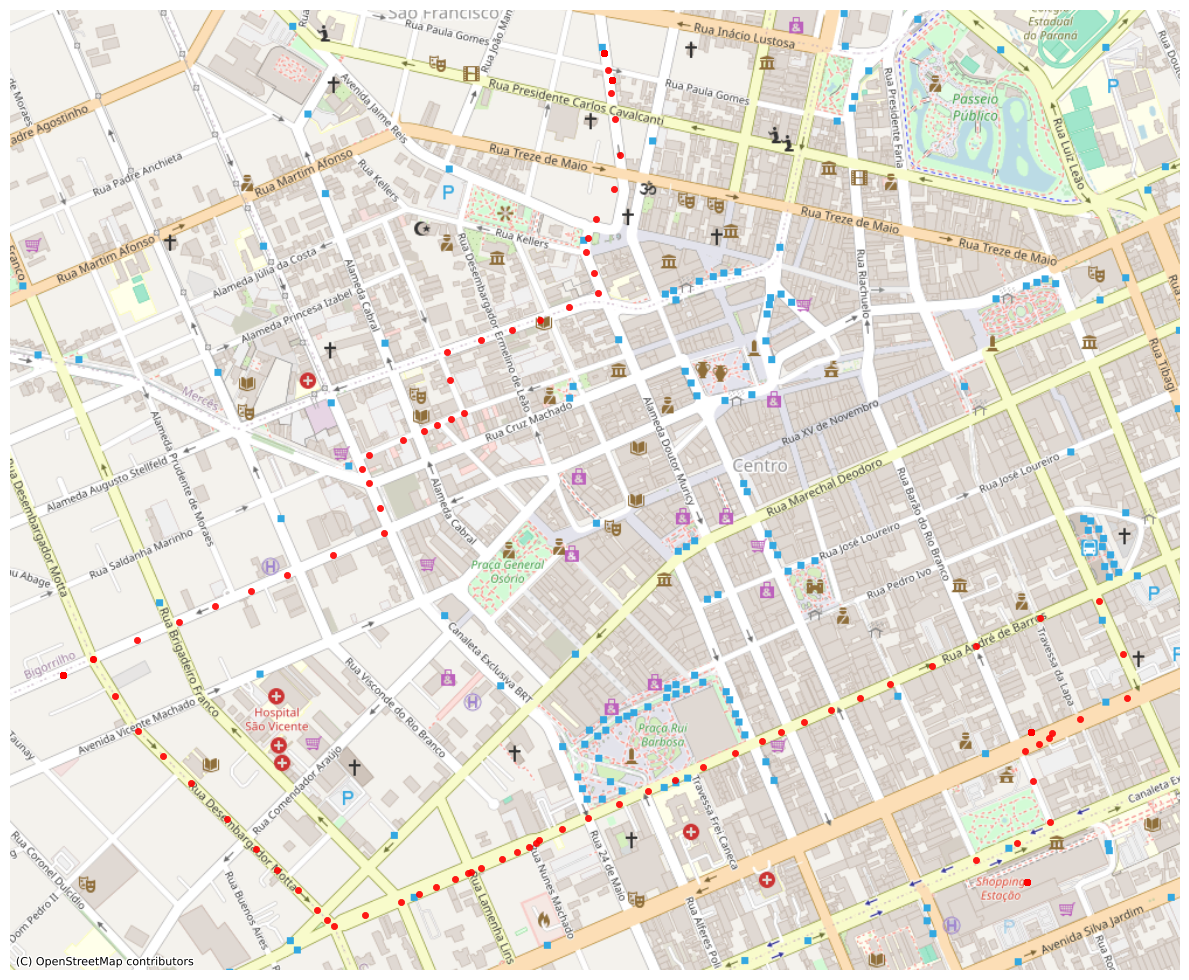

In [54]:
get_and_save_trajectory(12785992, "2014-05-17")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.4458363082, -49.2745713124) - Doctor's-Office at hour 8
2. (-25.4461018189, -49.274967317) - Advertising-Agency at hour 8
3. (-25.4317210104, -49.3395424626) - Building at hour 9
4. (-25.432466876, -49.3412867188) - Brazilian at hour 13
5. (-25.4304909982, -49.3386950601) - Hardware at hour 13

Center coordinates: (np.float64(-25.43732340234), np.float64(-49.313812574180005))
Downloaded street network with 25818 nodes and 65091 edges
Found nearest network nodes: [ 564252736  564252736 1701936389 1734753751 1387925419]
Segment 1: 1 nodes, 0 meters
Segment 2: 74 nodes, 8108 meters
Segment 3: 26 nodes, 2715 meters
Segment 4: 12 nodes, 1065 meters

Total trajectory: 110 nodes, 11888 meters total distance
Segment 1: Distance=0m, Travel time=0.0min, Stay time=0.0min
Segment 2: Distance=8108m, Travel time=24.3min, Stay time=35.7min
Segment 3: Distance=2715m, Travel time=8.1min, Stay time=231.9min
Segment 4: Distance=1065m, Travel t

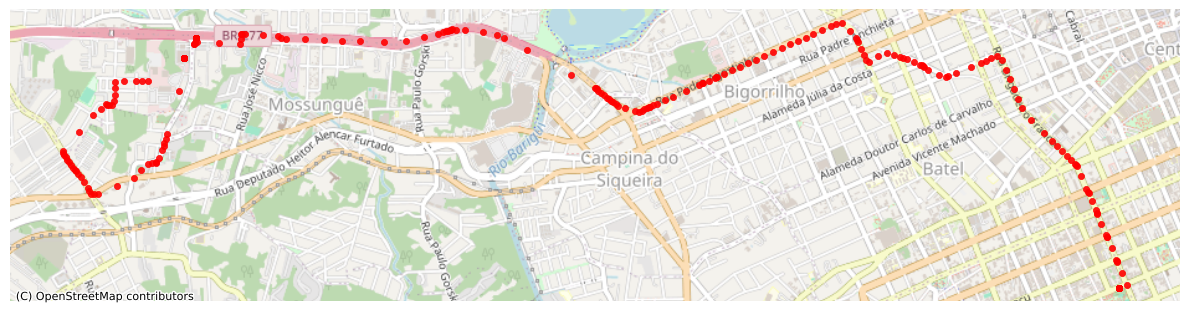

In [59]:
get_and_save_trajectory(6841680, "2014-05-27")

Number of check-ins: 5
Check-in locations (lat, lon):
1. (-25.4507046835, -49.2871853947) - Office at hour 15
2. (-25.4614806175, -49.2624378204) - Automotive at hour 17
3. (-25.4709372841, -49.291502935) - Gym at hour 20
4. (-25.4234314263, -49.2705059052) - Cineplex at hour 21
5. (-25.4641253467, -49.268935966) - Home at hour 22

Center coordinates: (np.float64(-25.45413587162), np.float64(-49.276113604260004))
Downloaded street network with 33402 nodes and 86343 edges
Found nearest network nodes: [  267194209   589264222 12603716397  5268327334  8481892110]
Segment 1: 32 nodes, 3885 meters
Segment 2: 38 nodes, 4080 meters
Segment 3: 72 nodes, 7411 meters
Segment 4: 54 nodes, 5318 meters

Total trajectory: 193 nodes, 20694 meters total distance
Segment 1: Distance=3885m, Travel time=11.7min, Stay time=108.3min
Segment 2: Distance=4080m, Travel time=12.2min, Stay time=167.8min
Segment 3: Distance=7411m, Travel time=22.2min, Stay time=37.8min
Segment 4: Distance=5318m, Travel time=16.0

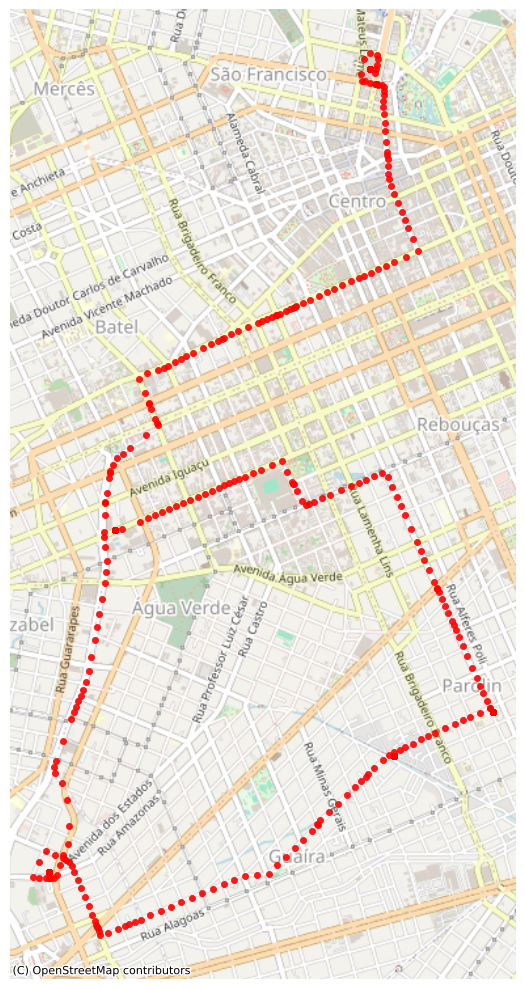

In [60]:
get_and_save_trajectory(5896225, "2014-05-19")

# Old

In [43]:
def create_location_intervals(current_row, base_date, time_at_location):
    """
    Create 10-second intervals for time spent at a specific location.
    
    Returns:
        List of dictionaries with timestamp, lat, lon
    """
    location_data = []
    
    # Create timestamp from hour
    current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
    
    # Generate 10-second intervals for time at this location
    intervals_at_location = (time_at_location * 60) // 10  # Convert to 10-second intervals
    
    for j in range(int(intervals_at_location)):
        timestamp = current_timestamp + timedelta(seconds=j * 10)
        
        location_data.append({
            'timestamp': timestamp,
            'lat': current_row['LAT'],
            'lon': current_row['LONG']
        })
    
    return location_data

def create_travel_intervals(current_row, next_row, base_date, time_at_location, travel_time_minutes):
    """
    Create 10-second intervals for travel time between two locations.
    
    Returns:
        List of dictionaries with timestamp, lat, lon (interpolated coordinates)
    """
    travel_data = []
    
    if travel_time_minutes <= 0:
        return travel_data
    
    # Calculate travel start time
    current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
    travel_start = current_timestamp + timedelta(minutes=time_at_location)
    
    # Generate travel coordinates
    travel_intervals = int((travel_time_minutes * 60) // 10)  # 10-second intervals
    
    if travel_intervals > 0:
        # Interpolate coordinates along the route
        for k in range(travel_intervals):
            progress = k / travel_intervals if travel_intervals > 1 else 0
            
            # Linear interpolation between start and end points
            start_lat, start_lon = current_row['LAT'], current_row['LONG']
            end_lat, end_lon = next_row['LAT'], next_row['LONG']
            
            interpolated_lat = start_lat + (end_lat - start_lat) * progress
            interpolated_lon = start_lon + (end_lon - start_lon) * progress
            
            travel_timestamp = travel_start + timedelta(seconds=k * 10)
            
            travel_data.append({
                'timestamp': travel_timestamp,
                'lat': interpolated_lat,
                'lon': interpolated_lon
            })
    
    return travel_data

def create_detailed_trajectory(sample_df, full_route, G, nodes):
    """
    Create a detailed trajectory with 10-second intervals including:
    - Time at each location
    - Travel time between locations
    - Only coordinates and timestamps
    """
    
    trajectory_data = []
    
    # Sort by hour to ensure chronological order
    sample_df_sorted = sample_df.sort_values('HOUR').reset_index(drop=True)
    
    # Base date for the trajectory
    base_date = pd.to_datetime(sample_df_sorted.iloc[0]['DATE']).date()
    
    for i in range(len(sample_df_sorted)):
        current_row = sample_df_sorted.iloc[i]
        
        # Estimate time spent at each location
        if i < len(sample_df_sorted) - 1:
            next_hour = int(sample_df_sorted.iloc[i + 1]['HOUR'])
            hours_diff = next_hour - int(current_row['HOUR'])
            
            # Assume 80% of time at location, 20% traveling
            time_at_location = int(hours_diff * 60 * 0.8)
        else:
            # Last location - assume 1 hour
            time_at_location = 60
        
        # Generate location intervals (staying at the location)
        location_intervals = create_location_intervals(current_row, base_date, time_at_location)
        trajectory_data.extend(location_intervals)
        
        # Generate travel intervals to next location (if not last location)
        if i < len(sample_df_sorted) - 1:
            next_row = sample_df_sorted.iloc[i + 1]
            next_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(next_row['HOUR']))
            current_timestamp = datetime.combine(base_date, datetime.min.time()) + timedelta(hours=int(current_row['HOUR']))
            
            # Calculate travel time (remaining time between check-ins)
            travel_start = current_timestamp + timedelta(minutes=time_at_location)
            travel_time_minutes = (next_timestamp - travel_start).total_seconds() / 60
            
            # Generate travel intervals
            travel_intervals = create_travel_intervals(current_row, next_row, base_date, time_at_location, travel_time_minutes)
            trajectory_data.extend(travel_intervals)
    
    # Create DataFrame
    trajectory_df = pd.DataFrame(trajectory_data)
    trajectory_df = trajectory_df.sort_values('timestamp').reset_index(drop=True)
    
    return trajectory_df

In [44]:
# Generate the detailed trajectory
detailed_trajectory = create_detailed_trajectory(sample_df, full_route, G, nodes)

print(f"Generated trajectory with {len(detailed_trajectory)} data points (10-second intervals)")
print(f"Time span: {detailed_trajectory['timestamp'].min()} to {detailed_trajectory['timestamp'].max()}")
print(f"Total duration: {(detailed_trajectory['timestamp'].max() - detailed_trajectory['timestamp'].min()).total_seconds() / 3600:.2f} hours")

# Display sample of the data
print("\nFirst 20 rows of detailed trajectory:")
print(detailed_trajectory.head(20))

# Save to CSV for future use
output_file = '../dados/detailed_trajectory_user_53308444.csv'
detailed_trajectory.to_csv(output_file, index=False)
print(f"\nTrajectory saved to: {output_file}")

# Display some statistics
location_count = 0
travel_count = 0

# Count location vs travel points by checking if coordinates change
for i in range(1, len(detailed_trajectory)):
    if (detailed_trajectory.iloc[i]['lat'] == detailed_trajectory.iloc[i-1]['lat'] and 
        detailed_trajectory.iloc[i]['lon'] == detailed_trajectory.iloc[i-1]['lon']):
        location_count += 1
    else:
        travel_count += 1

print(f"\nDetailed Statistics:")
print(f"- Approximate stationary intervals: {location_count} ({location_count * 10 / 60:.1f} minutes)")
print(f"- Approximate travel intervals: {travel_count} ({travel_count * 10 / 60:.1f} minutes)")

detailed_trajectory

Generated trajectory with 4680 data points (10-second intervals)
Time span: 2014-05-19 07:00:00 to 2014-05-19 19:59:50
Total duration: 13.00 hours

First 20 rows of detailed trajectory:
             timestamp        lat       lon
0  2014-05-19 07:00:00 -25.374541 -49.22436
1  2014-05-19 07:00:10 -25.374541 -49.22436
2  2014-05-19 07:00:20 -25.374541 -49.22436
3  2014-05-19 07:00:30 -25.374541 -49.22436
4  2014-05-19 07:00:40 -25.374541 -49.22436
5  2014-05-19 07:00:50 -25.374541 -49.22436
6  2014-05-19 07:01:00 -25.374541 -49.22436
7  2014-05-19 07:01:10 -25.374541 -49.22436
8  2014-05-19 07:01:20 -25.374541 -49.22436
9  2014-05-19 07:01:30 -25.374541 -49.22436
10 2014-05-19 07:01:40 -25.374541 -49.22436
11 2014-05-19 07:01:50 -25.374541 -49.22436
12 2014-05-19 07:02:00 -25.374541 -49.22436
13 2014-05-19 07:02:10 -25.374541 -49.22436
14 2014-05-19 07:02:20 -25.374541 -49.22436
15 2014-05-19 07:02:30 -25.374541 -49.22436
16 2014-05-19 07:02:40 -25.374541 -49.22436
17 2014-05-19 07:02:50

,timestamp,lat,lon
0,2014-05-19 07:00:00,-25.374541,-49.224360
1,2014-05-19 07:00:10,-25.374541,-49.224360
2,2014-05-19 07:00:20,-25.374541,-49.224360
3,2014-05-19 07:00:30,-25.374541,-49.224360
4,2014-05-19 07:00:40,-25.374541,-49.224360
...,...,...,...
4675,2014-05-19 19:59:10,-25.392531,-49.229802
4676,2014-05-19 19:59:20,-25.392531,-49.229802
4677,2014-05-19 19:59:30,-25.392531,-49.229802
4678,2014-05-19 19:59:40,-25.392531,-49.229802


In [45]:
detailed_trajectory.to_csv('../dados/sample_detailed_trajectory_user_53308444.csv', index=False)